# State ISI and epoch durations (R3-18, R1-8)

Fig 3d plotters/bins unchanged. Active/quiet ISIs keep an interval only when **both** bounding saccades sit in the same raw behavior-state epoch (cross-epoch ISIs dropped).

**Epoch-duration bin trials** (section 3) use **smoothed** behavior state (bridge ≤3 s, min 5 s/state) — same filter as the reference `n≈174/191` plots. Zoom xmax = `ceil(max(active) / 5) * 5`.


## 0. Setup


In [1]:
%matplotlib inline
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

plt.ioff()

REPO = Path.cwd()
if not (REPO / "src" / "eye_tracking_system_tools").is_dir():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "src" / "eye_tracking_system_tools").is_dir():
            REPO = p
            break

sys.path.insert(0, str(REPO / "src"))
os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

from eye_tracking_system_tools.analysis.block_registry import load_registry
from eye_tracking_system_tools.analysis.event_cache import build_or_load_event_tables
from eye_tracking_system_tools.analysis.export_meta import load_params_yaml
from eye_tracking_system_tools.analysis.review_collect import review_answers_dir
from eye_tracking_system_tools.analysis.run_layout import resolve_figure_dirs

# Empty TAG overwrites outputs/review_answers_latest
TAG = ""
REGISTRY = REPO / "configs" / "paper_blocks.yaml"
PARAMS = REPO / "configs" / "analysis_params.yaml"
run = review_answers_dir(REPO / "outputs", TAG)
figures_dir, metadata_dir = resolve_figure_dirs(run)
print("REPO :", REPO)
print("run  :", run)
print("  figures :", figures_dir)
print("  metadata:", metadata_dir)

KEEP_TRACES = True


REPO : /Users/nimi/Projects/PETS
run  : /Users/nimi/Projects/PETS/outputs/review_answers_latest
  figures : /Users/nimi/Projects/PETS/outputs/review_answers_latest/plots
  metadata: /Users/nimi/Projects/PETS/outputs/review_answers_latest/metadata


## 1. Load event tables


In [2]:
params = load_params_yaml(PARAMS)
specs = load_registry(REGISTRY)
tables, cache_path, from_cache = build_or_load_event_tables(
    specs,
    params,
    metadata_dir,
    keep_traces=KEEP_TRACES,
    prefer_finalized=True,
)
print(f"blocks={len(tables.blocks)}  events={len(tables.all_saccades)}  cache={'hit' if from_cache else 'miss'}")
print(cache_path)


[PV_106_block_008] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_009] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_010] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_011] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_106_block_012] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_143_block_001] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)
[PV_143_block_002] eye CSVs: L=left_eye_data_degrees_raw_verified.csv (raw_verified), R=right_eye_data_degrees_raw_verified.csv (raw_verified)

## 2. Build ISI + baseline epoch durations

Writes `ISI_by_state/`, legacy `epoch_durations/` (raw CSV, log + linear, 30 bins), and `epoch_duration_bin_trials/` (smoothed-state triptych variants). For iteration on bins only, skip to section 3.


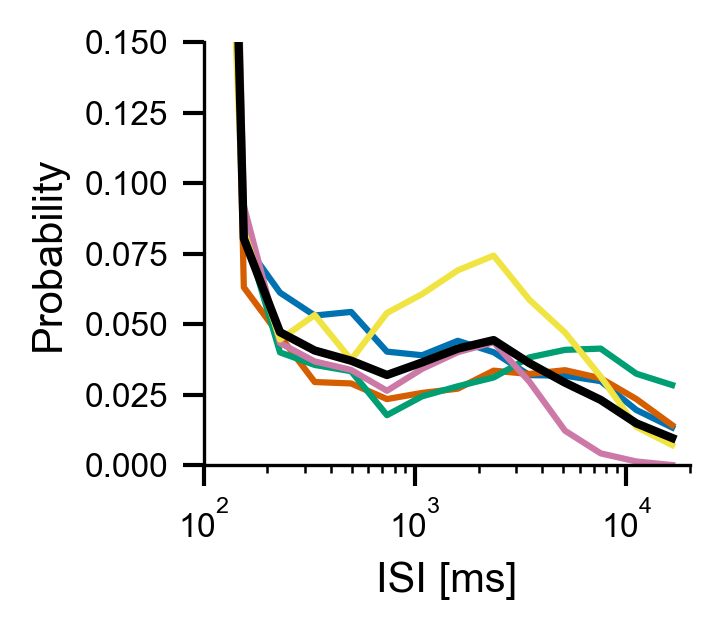

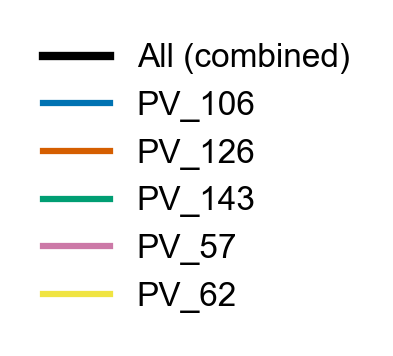

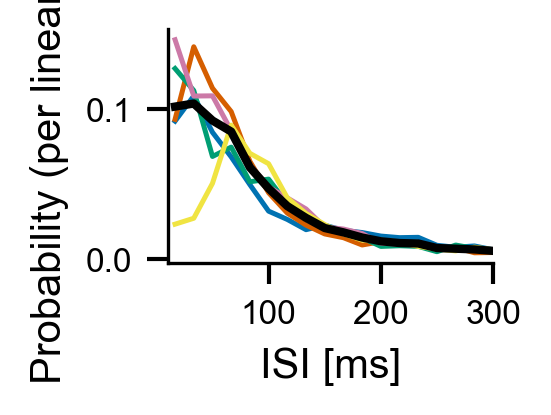

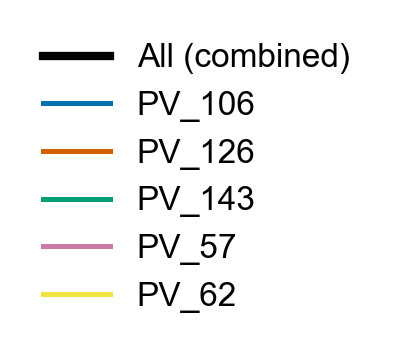

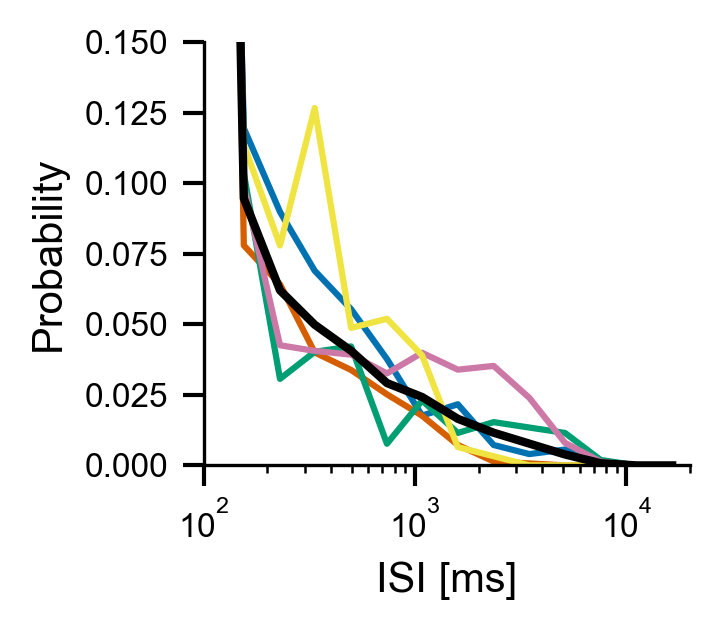

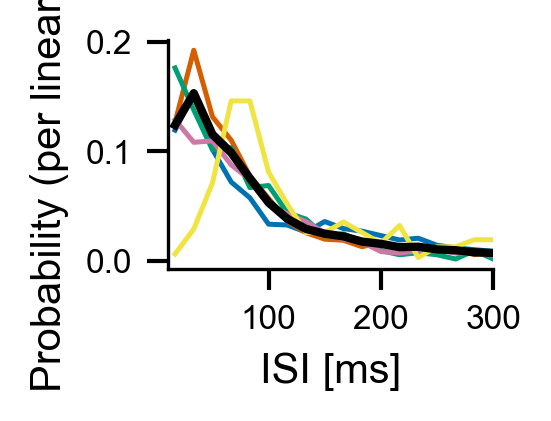

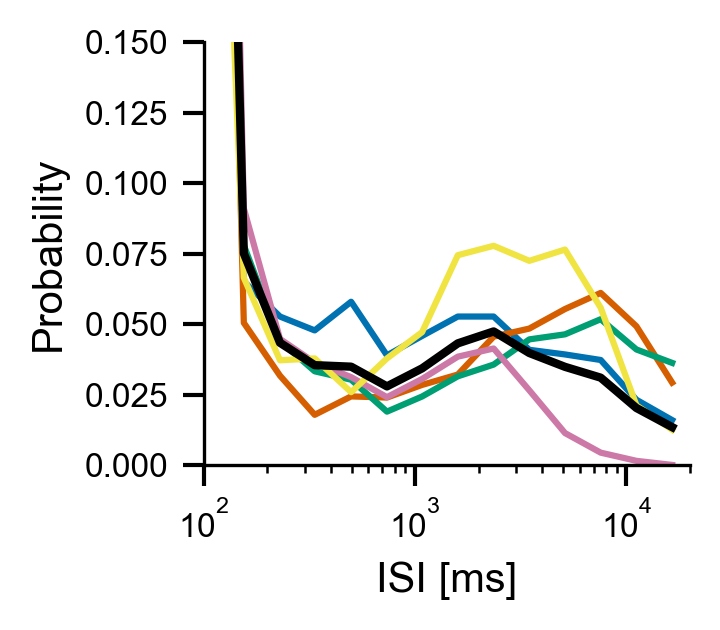

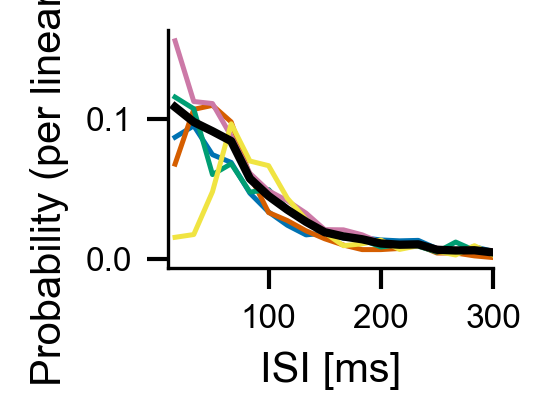

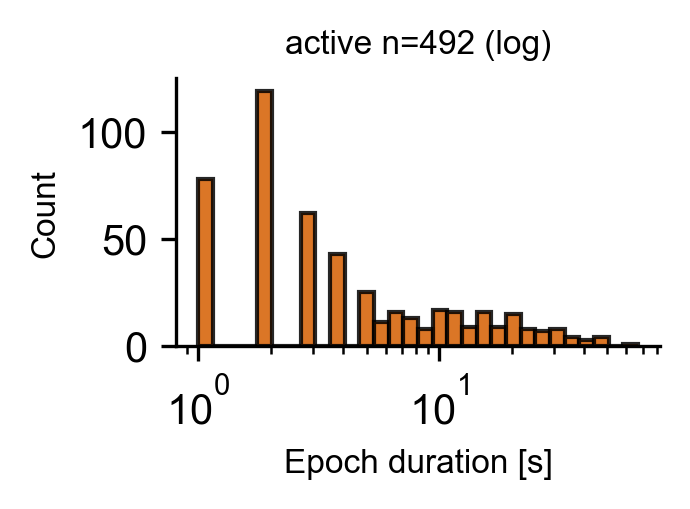

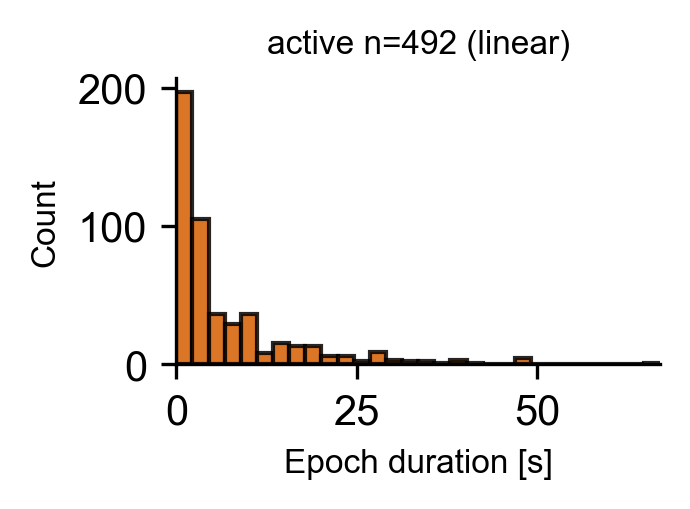

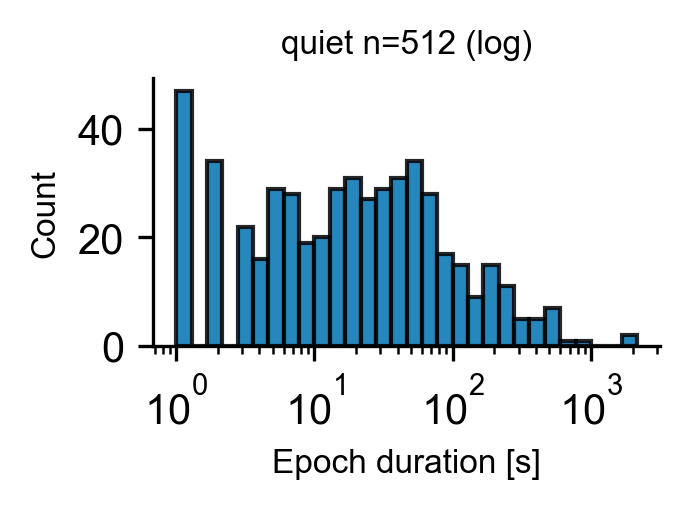

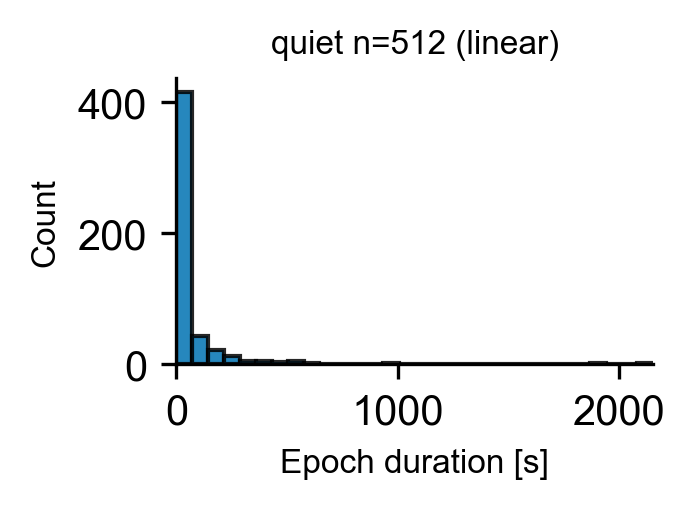

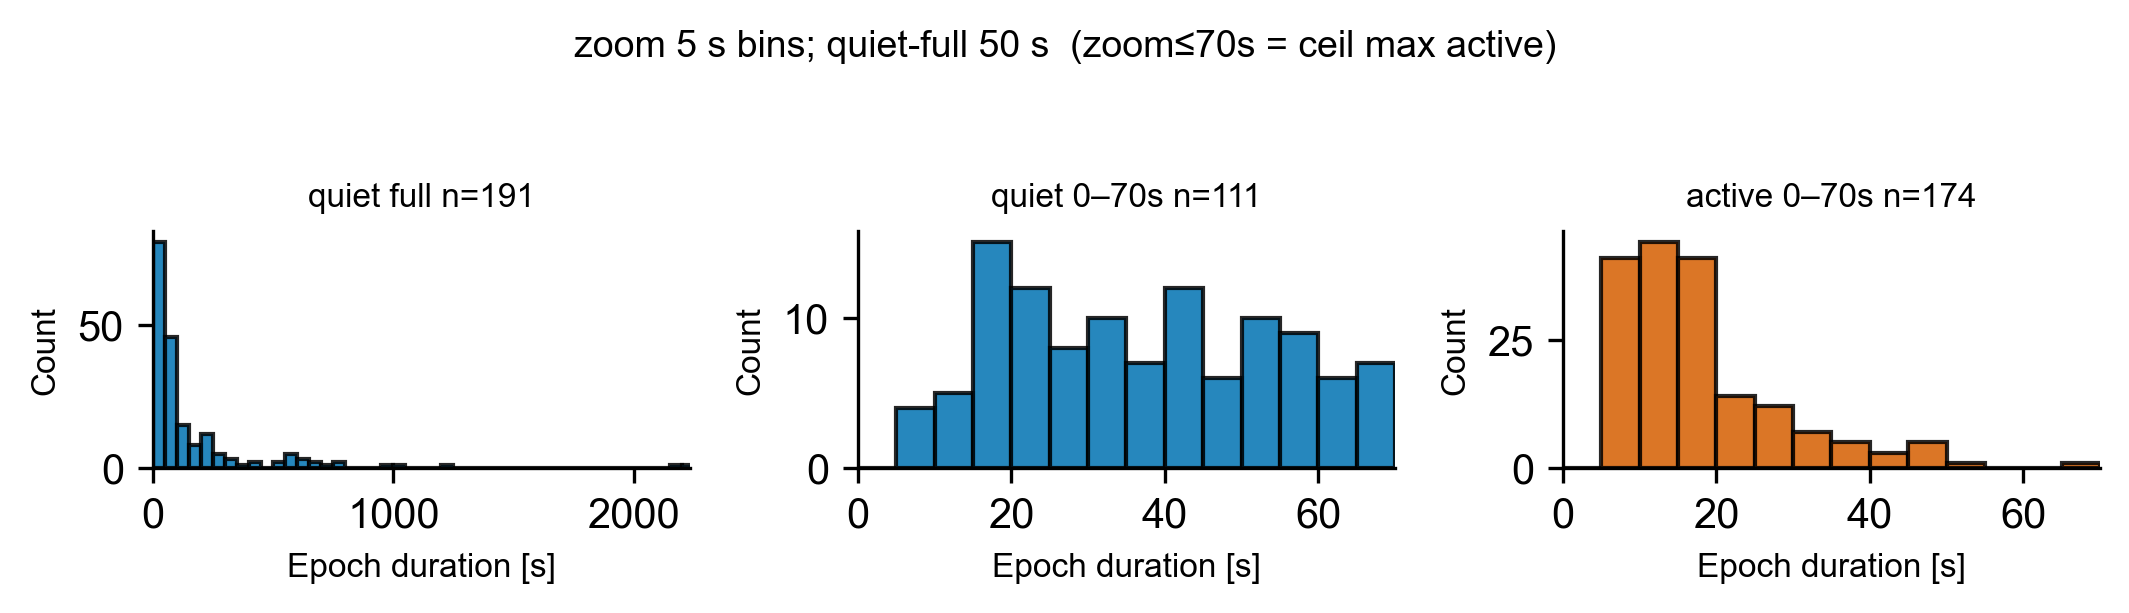

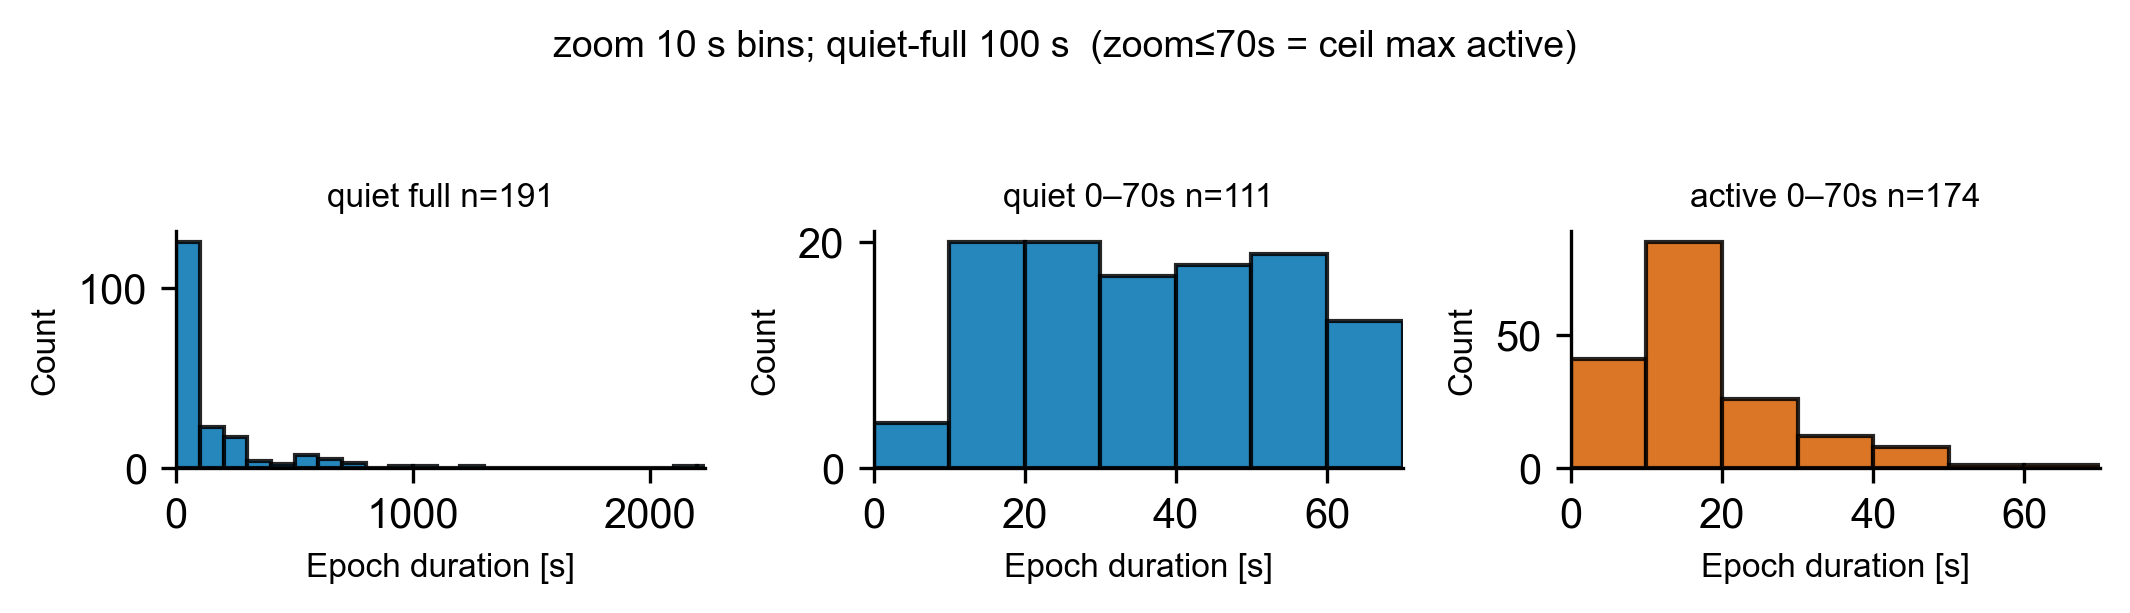

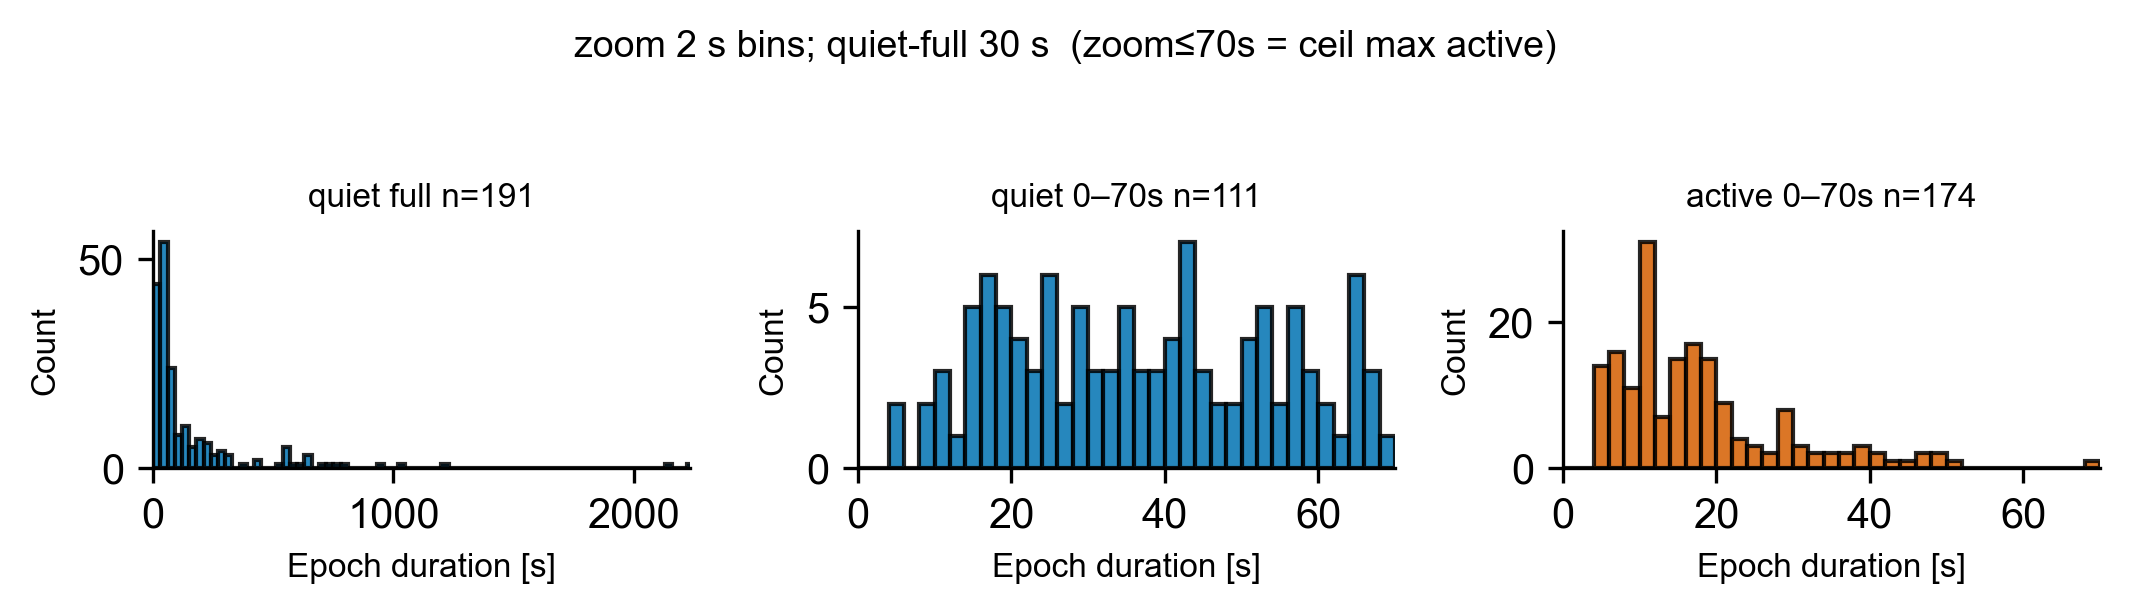

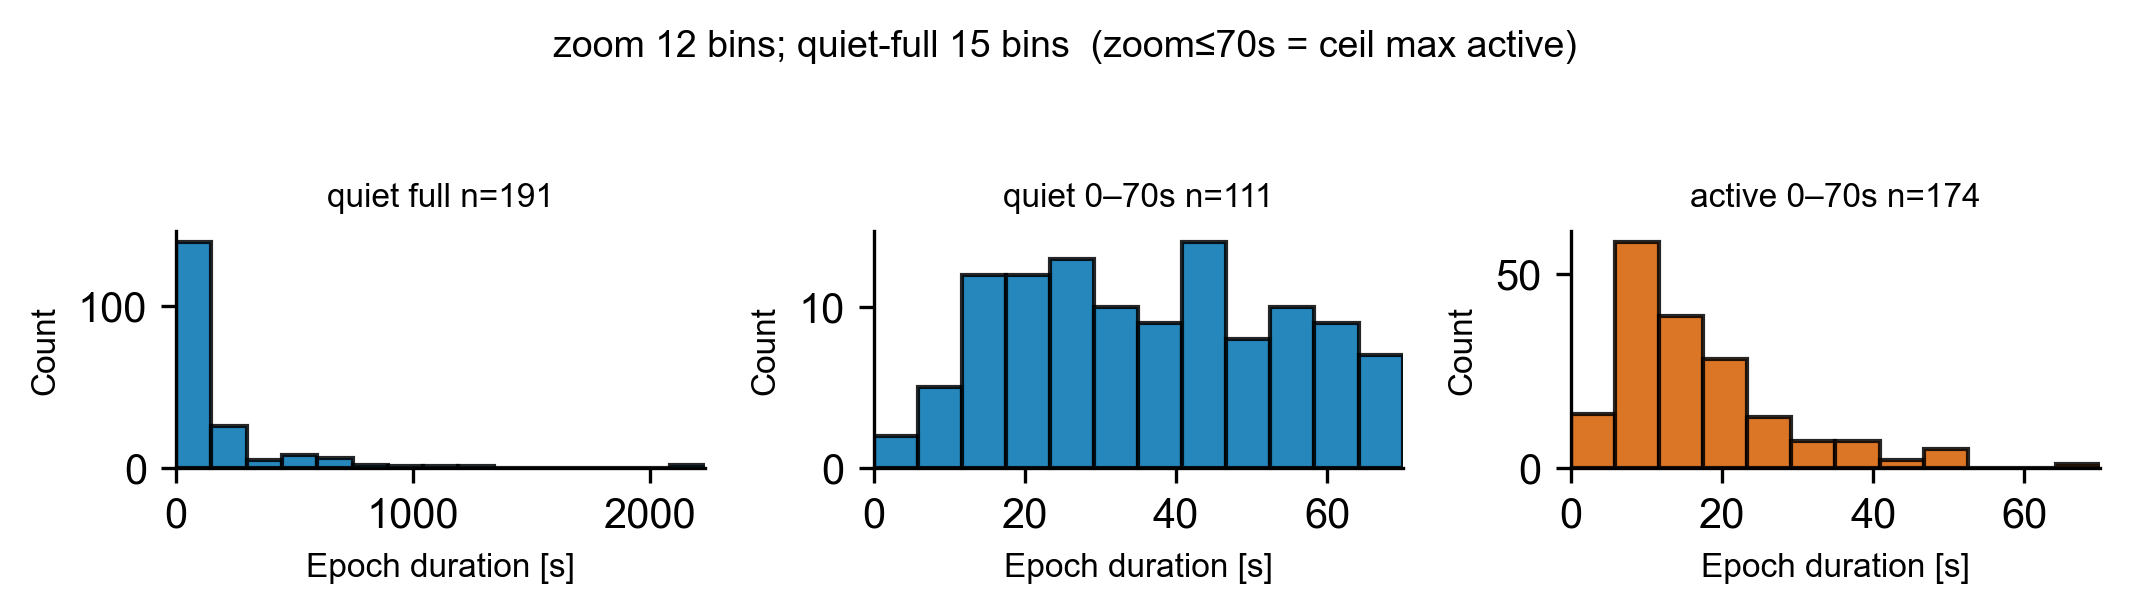

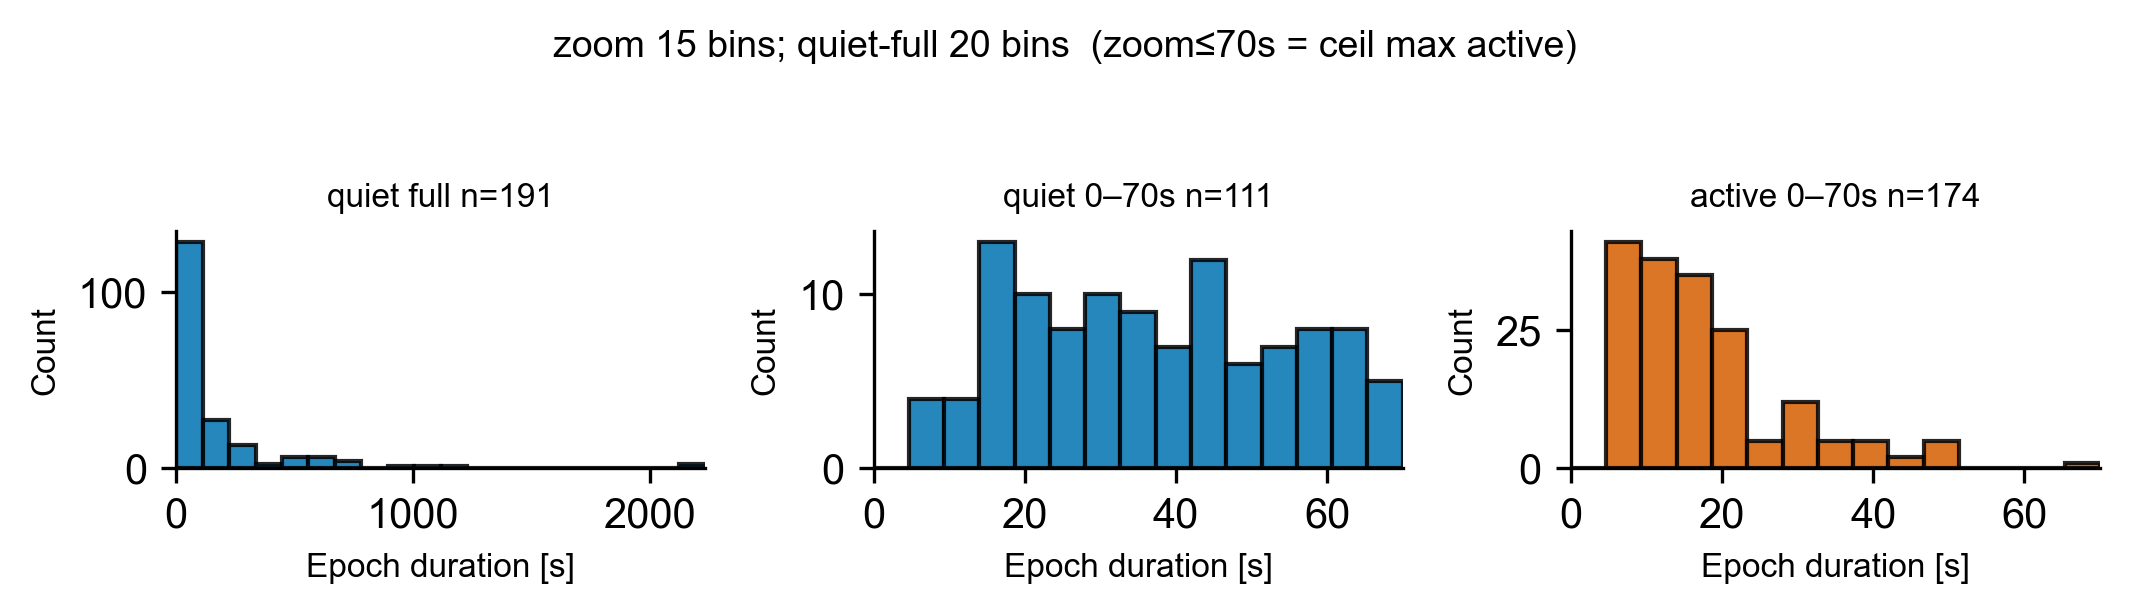

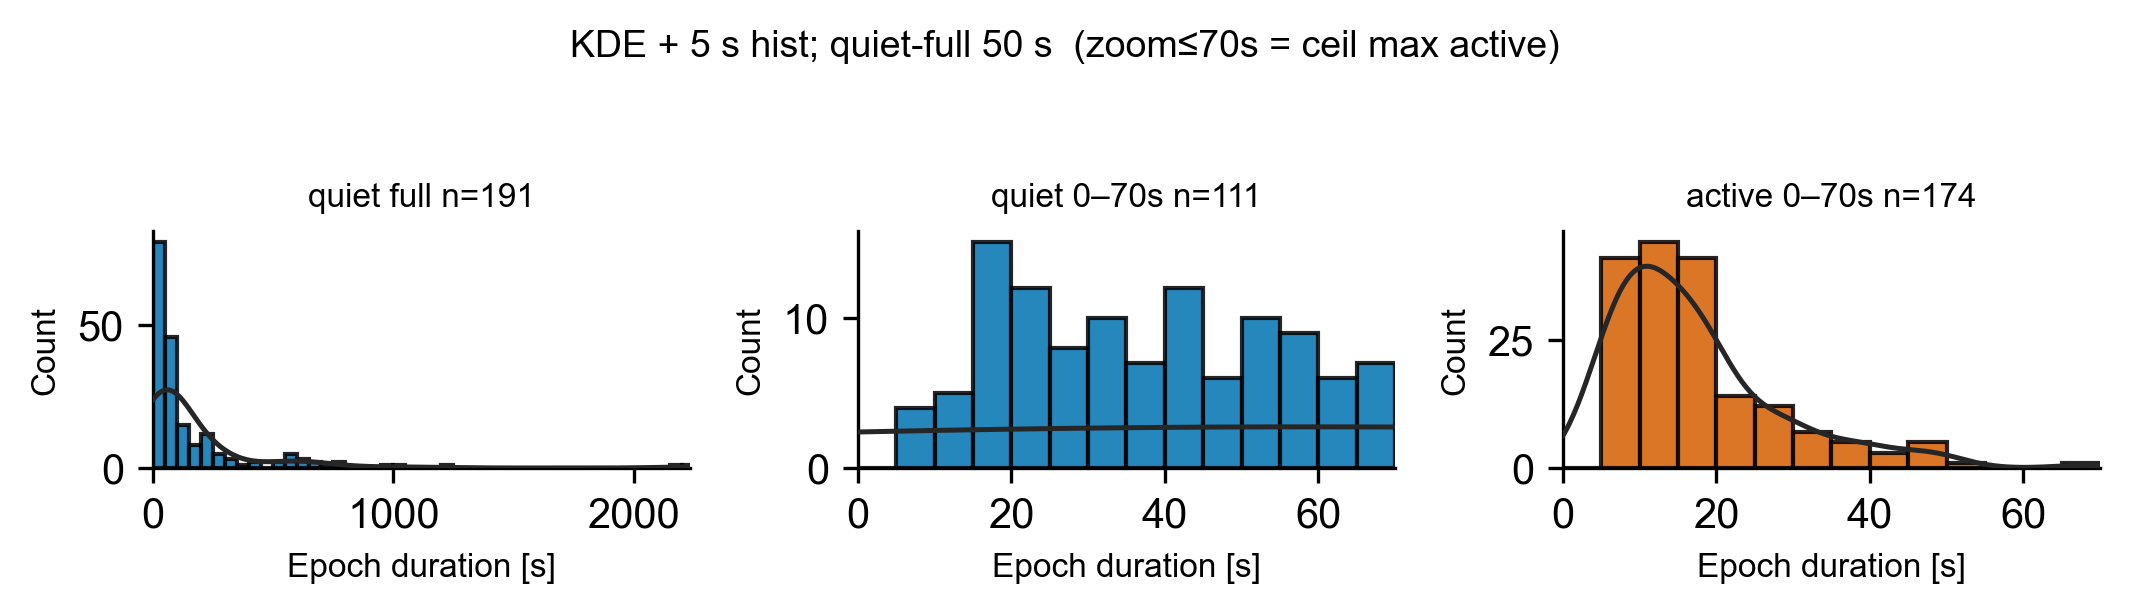

ISI_histogram → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/plots/ISI_histogram.pdf
legend_ISI_histogram → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/plots/legend_ISI_histogram.pdf
ISI_histogram_plotdata → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/metadata/ISI_histogram_plotdata.pickle
ISI_hist_linear_10_300ms → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/plots/ISI_hist_linear_10_300ms.pdf
legend_ISI_hist_linear_10_300ms → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/plots/legend_ISI_hist_linear_10_300ms.pdf
ISI_hist_linear_10_300ms_plotdata → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/metadata/ISI_hist_linear_10_300ms_plotdata.pickle
ISI_log_active.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_state/plots/ISI_log_active.pdf
ISI_linear_active.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/ISI_by_st

In [3]:
from eye_tracking_system_tools.analysis.figures_3d_isi import (
    EPOCH_DURATION_BIN_TRIALS,
    collect_epoch_durations,
    epoch_duration_zoom_xmax_s,
    export_state_isi_and_epochs,
)

written = export_state_isi_and_epochs(tables, run, show=True)
for name, path in written.items():
    print(name, "→", path)


## 3. Epoch-duration bin trials — how to run & tweak

**Launch (after sections 0–1 have been run once):**
1. Kernel: `eye_repo_mac`, working directory = repo root (or any cwd; the setup cell walks parents to find `src/`).
2. Run cells **0 → 1 → Setup → Load** once (builds/reuses the event cache).
3. Run **this section only** to re-export triptychs — no need to re-run ISI.

**Outputs:** `outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_*.pdf`  
(empty `TAG` in setup → `review_answers_latest`; set `TAG` for a dated snapshot).

**Where to tweak**

| What | Where |
|---|---|
| Bin schemes (widths / n_bins / KDE) | `EPOCH_DURATION_BIN_TRIALS` in `src/.../figures_3d_isi.py`, **or** pass a local `trials=[...]` list into `export_epoch_duration_bin_trials` below |
| Smoothed vs raw state | `SMOOTH_STATE` / `MIN_DURATION_S` in the next cell (`True`/`1.0` = reference n≈174/191; `False`/`0.0` = raw n≈492/512) |
| Zoom rounding | `ZOOM_ROUND_TO_S` (default 5 → xmax = ceil(max active / 5)×5) |
| Cohort / params | `REGISTRY` / `PARAMS` in the setup cell |
| Run folder | `TAG` in the setup cell |

Each PDF is **quiet full-range | quiet 0–zoom | active 0–zoom** (shared zoom from longest active epoch).


smooth=True  active n=174  min=5  median=15  max=68  → zoom_xmax=70s
quiet  n=191  min=5  median=58.999  max=2234  | within zoom: 111/191
trials:
  width5s_quiet50s — zoom 5 s bins; quiet-full 50 s
  width10s_quiet100s — zoom 10 s bins; quiet-full 100 s
  width2s_quiet30s — zoom 2 s bins; quiet-full 30 s
  nbins12_quiet15 — zoom 12 bins; quiet-full 15 bins
  nbins15_quiet20 — zoom 15 bins; quiet-full 20 bins
  kde_width5s_quiet50s — KDE + 5 s hist; quiet-full 50 s


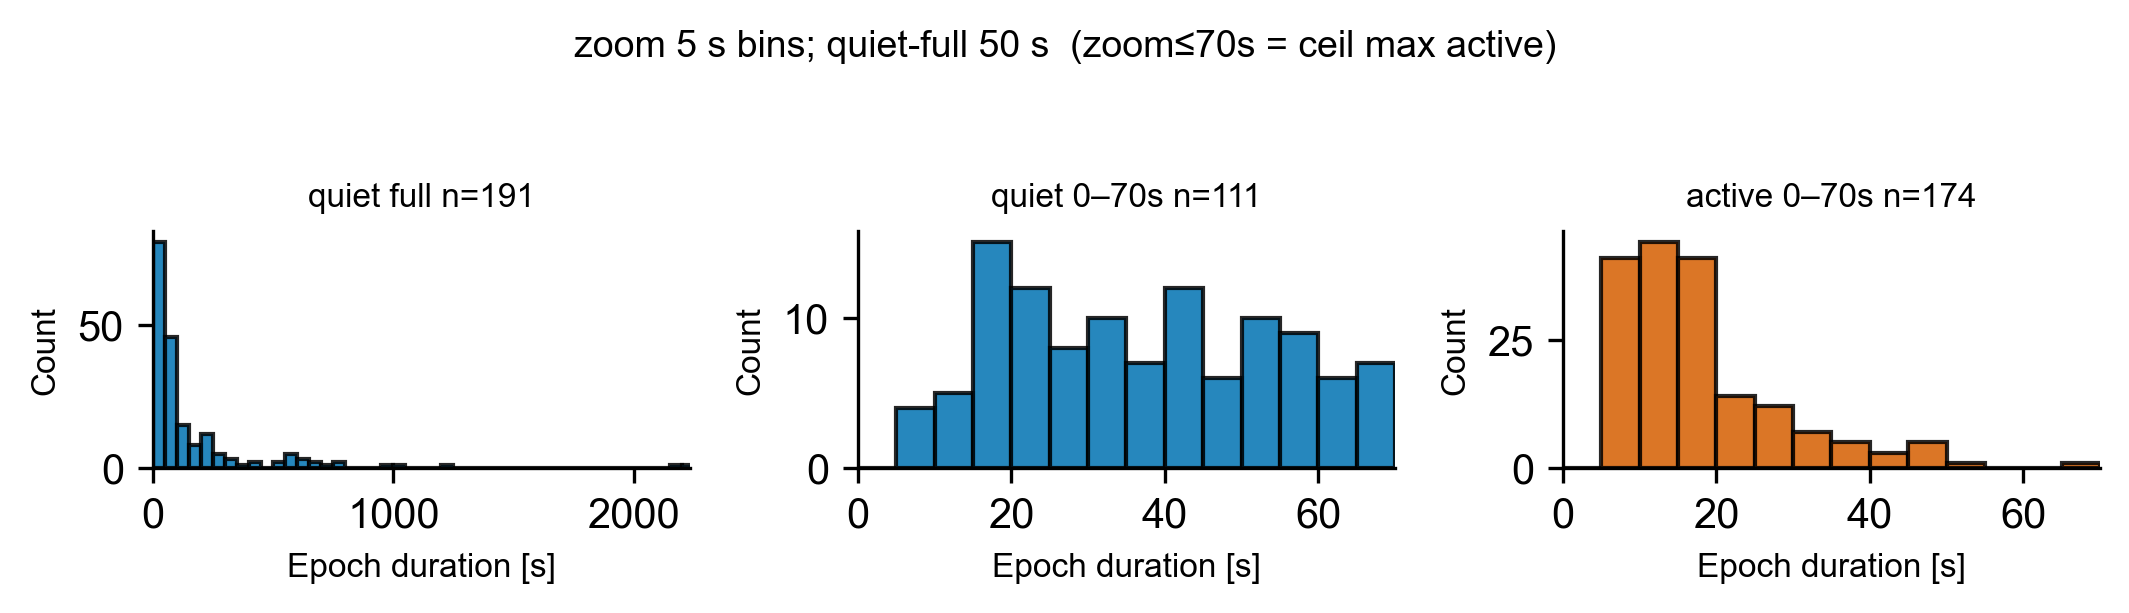

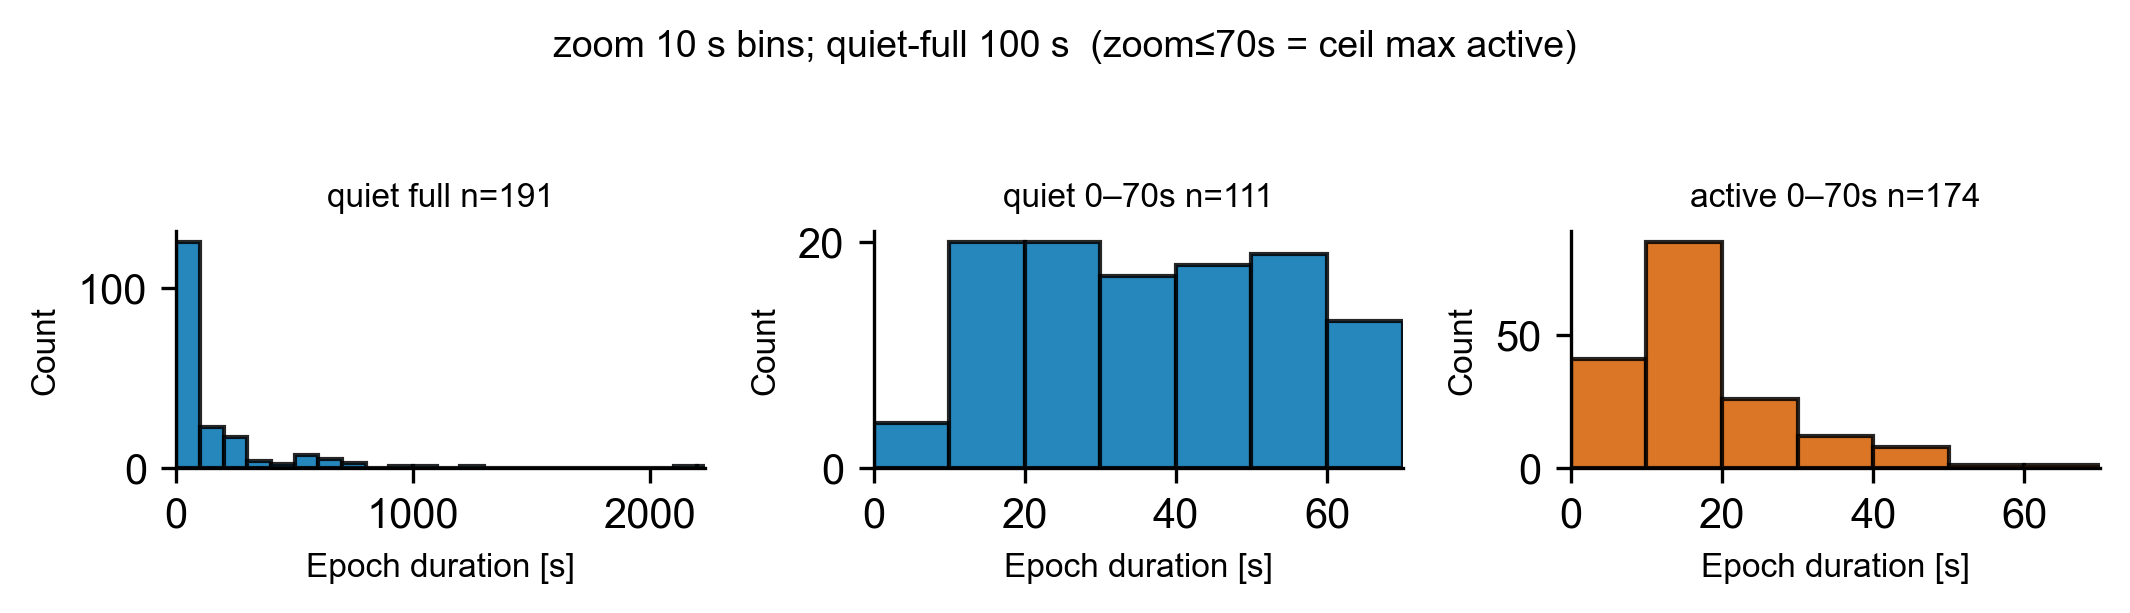

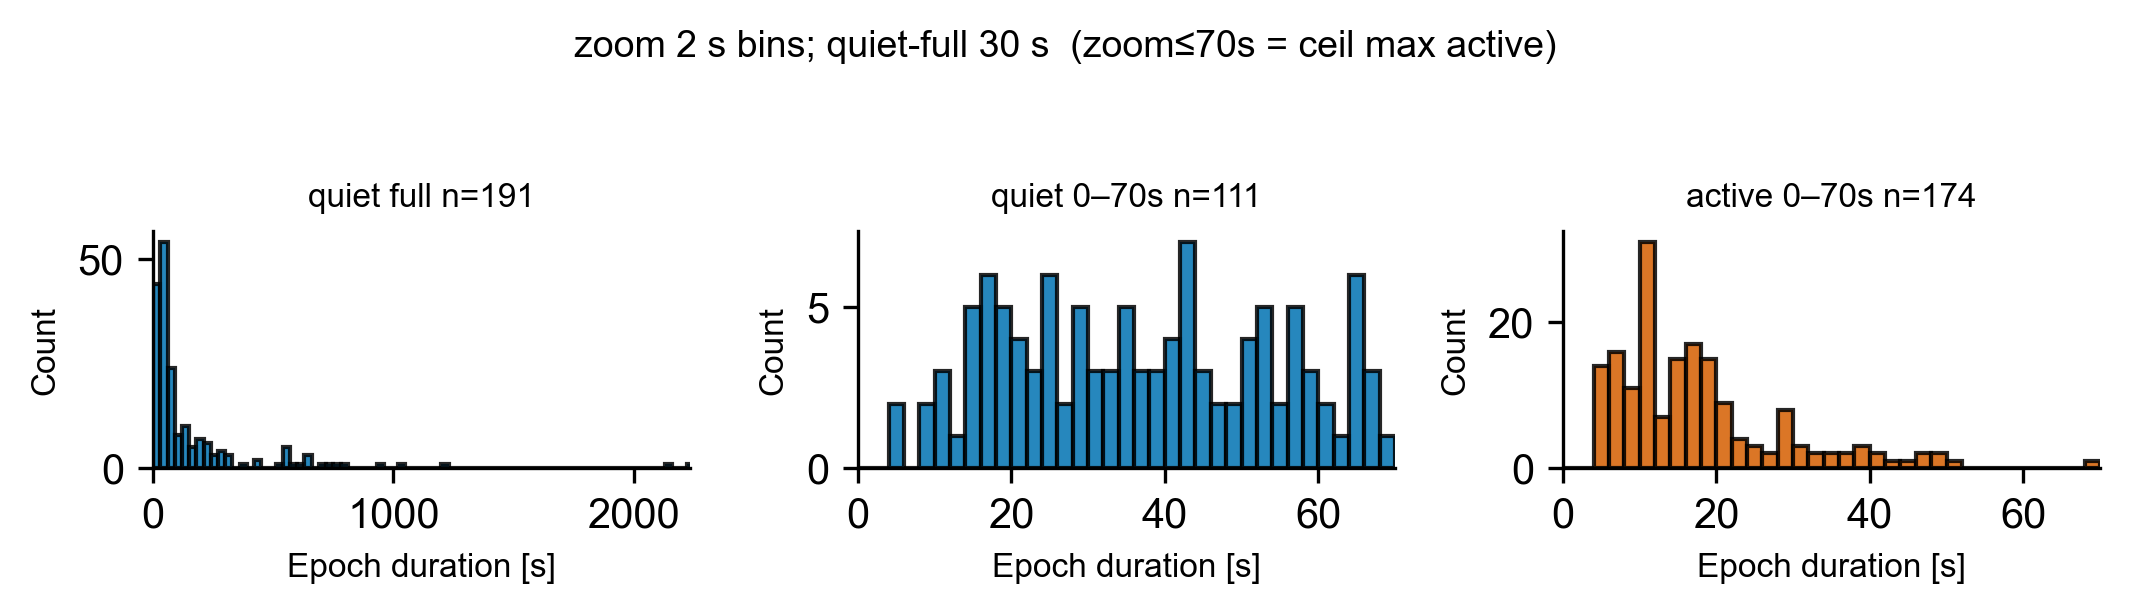

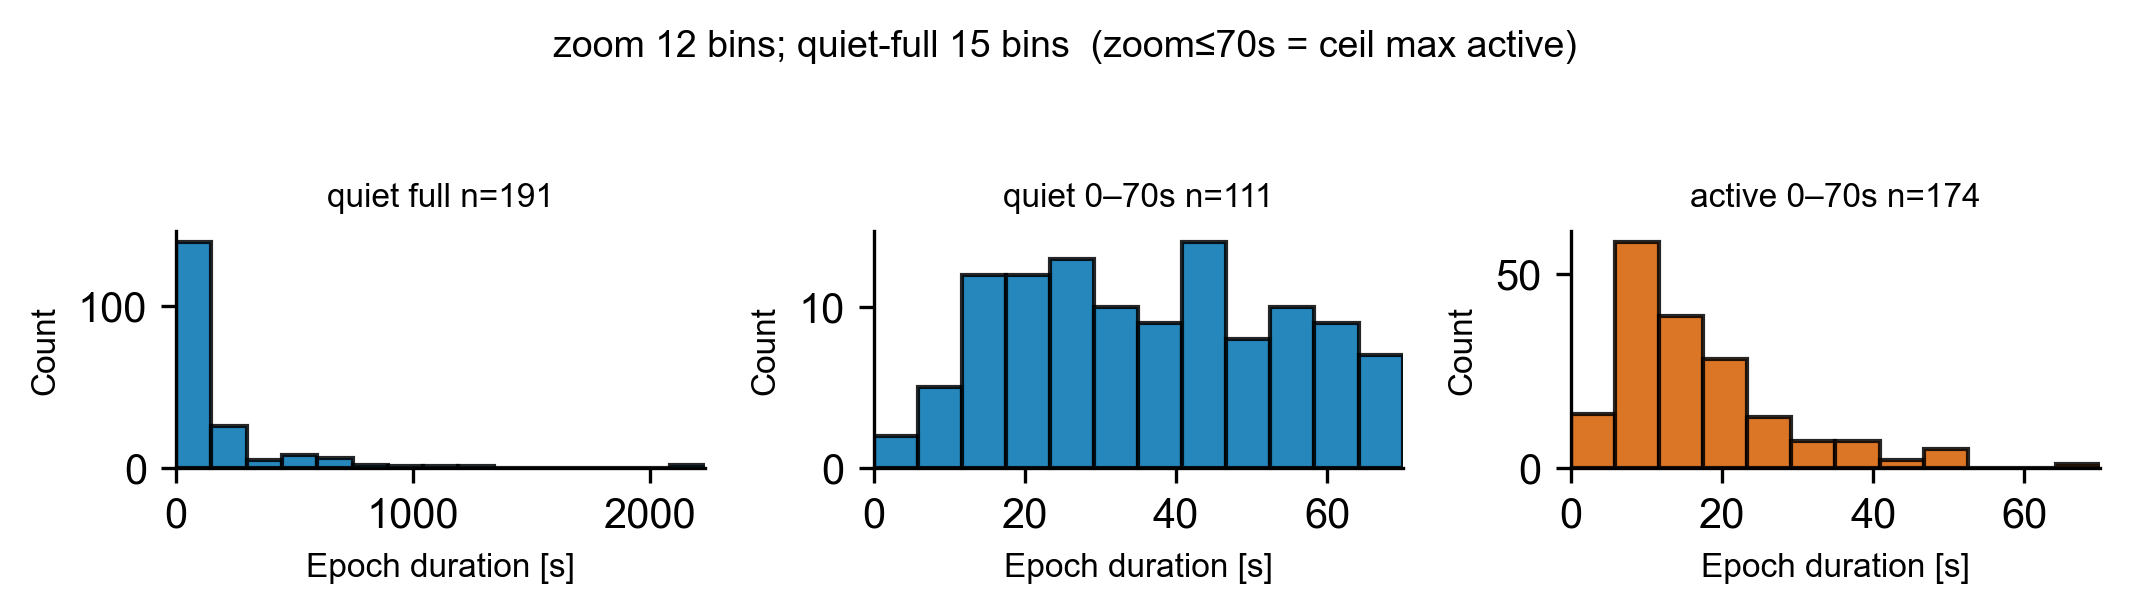

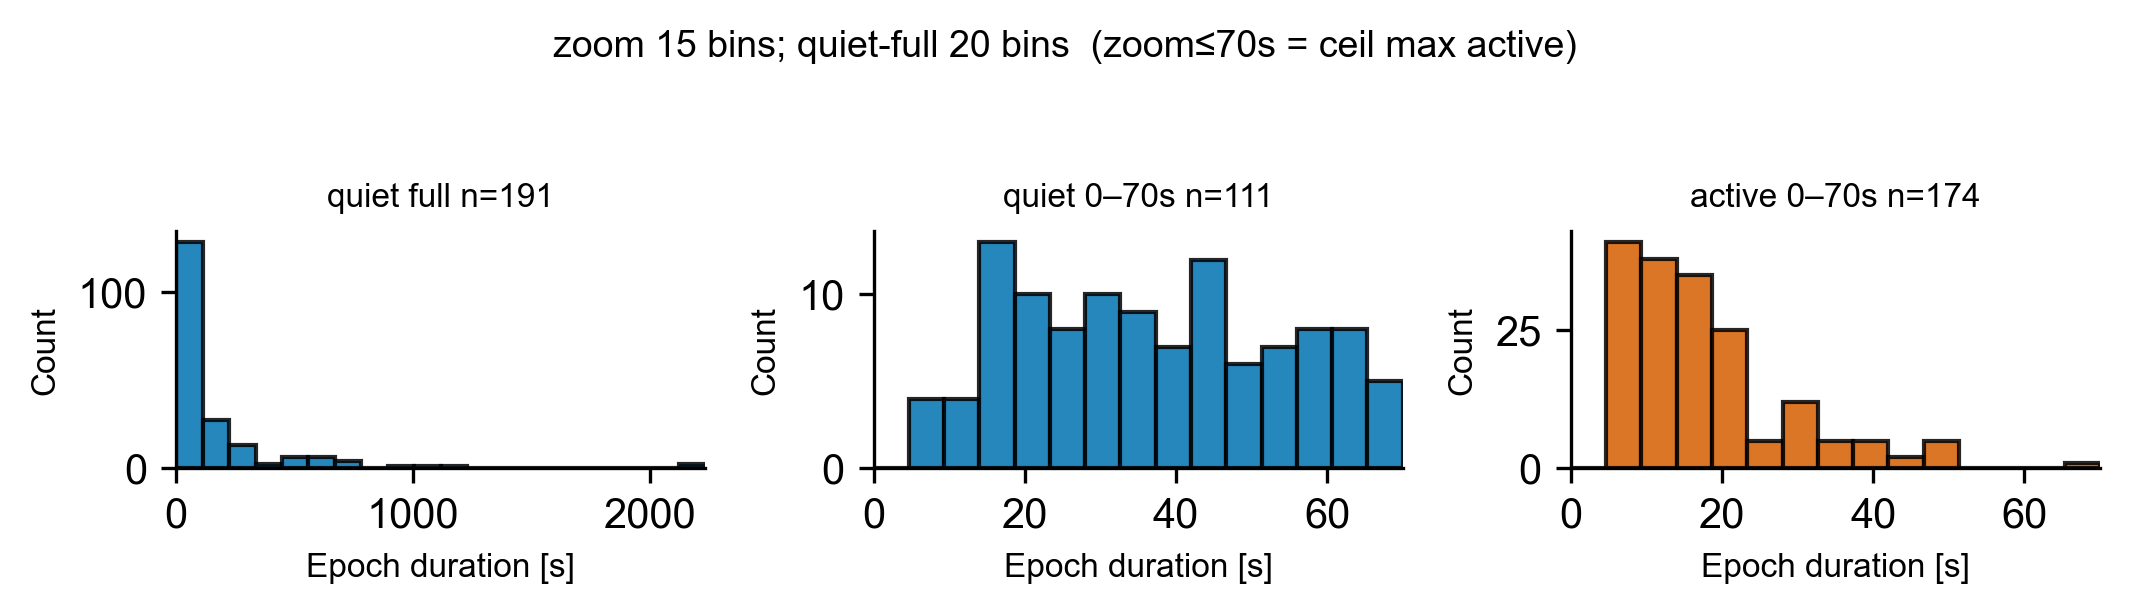

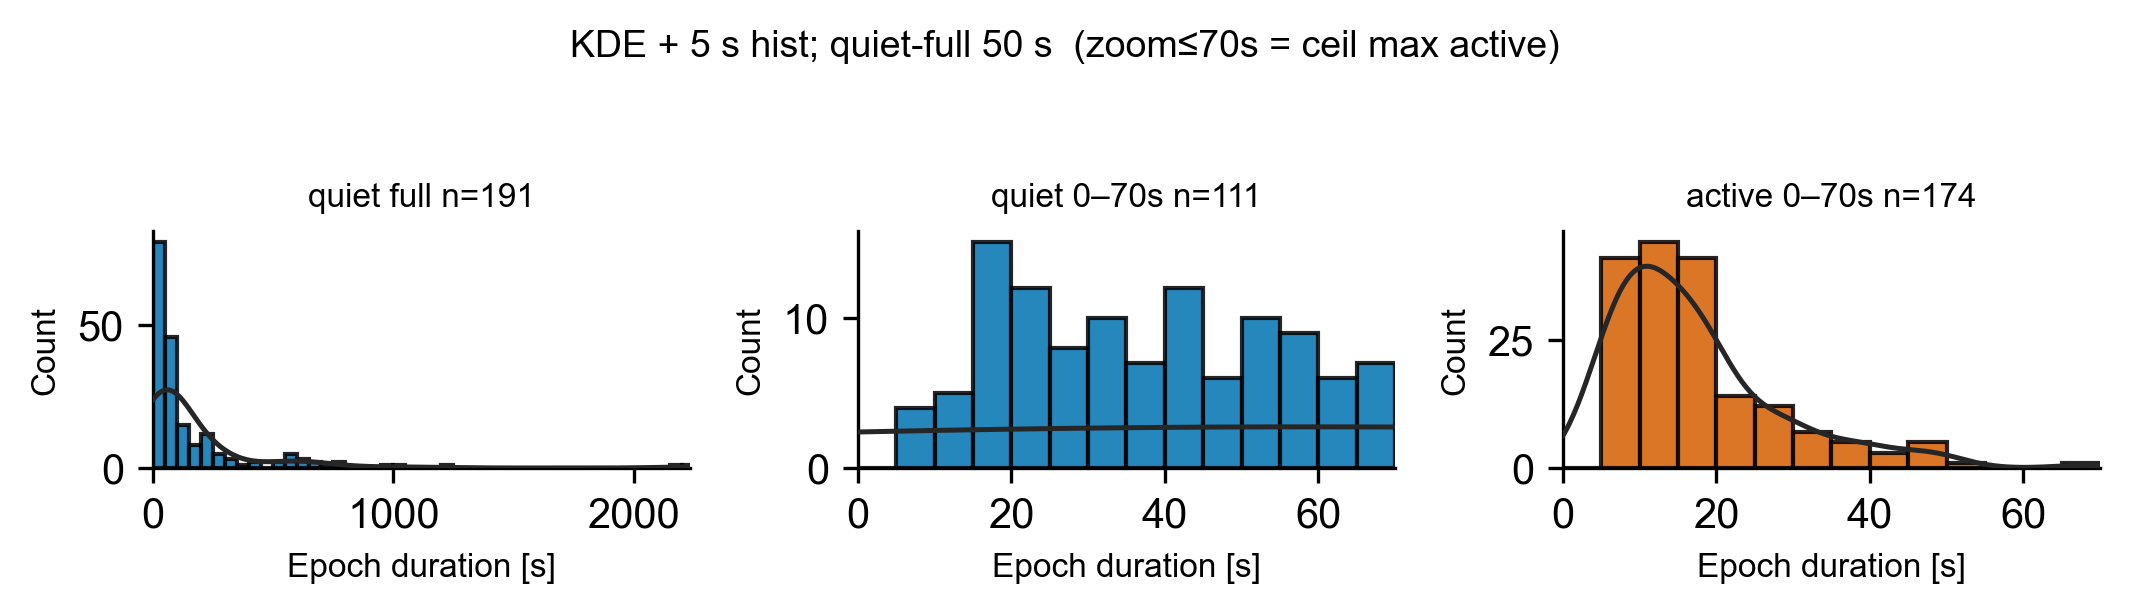

wrote:
epoch_duration_triptych_width5s_quiet50s.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_width5s_quiet50s.pdf
epoch_duration_triptych_width10s_quiet100s.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_width10s_quiet100s.pdf
epoch_duration_triptych_width2s_quiet30s.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_width2s_quiet30s.pdf
epoch_duration_triptych_nbins12_quiet15.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_nbins12_quiet15.pdf
epoch_duration_triptych_nbins15_quiet20.pdf → /Users/nimi/Projects/PETS/outputs/review_answers_latest/epoch_duration_bin_trials/plots/epoch_duration_triptych_nbins15_quiet20.pdf
epoch_duration_triptych_kde_width5s_quiet50s.pdf → /Users/nimi/Projects/PETS/outputs/review_a

In [4]:
from eye_tracking_system_tools.analysis.figures_3d_isi import export_epoch_duration_bin_trials
import numpy as np

# --- tweak here ---
SMOOTH_STATE = True          # True → match reference (~174/191); False → raw (~492/512)
MIN_DURATION_S = 1.0         # drop epochs shorter than this (smoothed bundle uses 1.0)
ZOOM_ROUND_TO_S = 5.0        # zoom xmax = ceil(max_active / this) * this
# Optional: override schemes without editing the library, e.g.
# TRIALS = [{"name": "width10s_quiet100s", "zoom_bin_width_s": 10.0, "quiet_full_bin_width_s": 100.0, "label": "10 s zoom"}]
TRIALS = None                # None → use EPOCH_DURATION_BIN_TRIALS from figures_3d_isi.py
# ------------------

durs = collect_epoch_durations(
    tables, smooth_state=SMOOTH_STATE, min_duration_s=MIN_DURATION_S
)
active = np.asarray(durs["active"], float)
quiet = np.asarray(durs["quiet"], float)
zoom_xmax = epoch_duration_zoom_xmax_s(active, round_to=ZOOM_ROUND_TO_S)
print(
    f"smooth={SMOOTH_STATE}  active n={active.size}  min={active.min():g}  "
    f"median={np.median(active):g}  max={active.max():g}  → zoom_xmax={zoom_xmax:g}s"
)
print(
    f"quiet  n={quiet.size}  min={quiet.min():g}  median={np.median(quiet):g}  "
    f"max={quiet.max():g}  | within zoom: {(quiet <= zoom_xmax).sum()}/{quiet.size}"
)
schemes = TRIALS if TRIALS is not None else EPOCH_DURATION_BIN_TRIALS
print("trials:")
for t in schemes:
    print(" ", t["name"], "—", t.get("label", ""))

trial_written = export_epoch_duration_bin_trials(
    tables,
    run,
    show=True,
    trials=TRIALS,
    zoom_round_to_s=ZOOM_ROUND_TO_S,
    smooth_state=SMOOTH_STATE,
    min_duration_s=MIN_DURATION_S,
)
print("wrote:")
for name, path in trial_written.items():
    print(name, "→", path)


## 4. Longest quiet epochs (smoothed) — visual QC list

Top **10%** longest quiet epochs after the same smoothing as section 3. Times are the behavior-state CSV clocks (**ms**); also shown in seconds for convenience. Use the row index in section 5 to open that block in the preprocessing GUI (Behavior tab).


In [5]:
import numpy as np
from eye_tracking_system_tools.analysis.figures_3d_isi import collect_epoch_table

# Match section 3 defaults (smoothed reference counts).
QC_SMOOTH = True
QC_MIN_DURATION_S = 1.0
TOP_FRACTION = 0.10  # longest 10% of quiet epochs

epoch_table = collect_epoch_table(
    tables, smooth_state=QC_SMOOTH, min_duration_s=QC_MIN_DURATION_S
)
quiet_epochs = epoch_table.loc[epoch_table["state"] == "quiet"].copy()
n_quiet = len(quiet_epochs)
n_top = max(1, int(np.ceil(TOP_FRACTION * n_quiet)))
longest_quiet = (
    quiet_epochs.nlargest(n_top, "duration_s")
    .reset_index(drop=True)
)
longest_quiet.index.name = "epoch_i"

display_cols = [
    "animal",
    "block_num",
    "duration_s",
    "start_time_ms",
    "end_time_ms",
    "start_s",
    "end_s",
    "block_key",
    "block_path",
]
print(
    f"quiet epochs={n_quiet}  showing top {n_top} "
    f"({100 * TOP_FRACTION:.0f}%)  smooth={QC_SMOOTH}"
)
print(
    f"duration_s range in list: "
    f"{longest_quiet['duration_s'].min():.1f} – {longest_quiet['duration_s'].max():.1f}"
)
longest_quiet[display_cols]


quiet epochs=191  showing top 20 (10%)  smooth=True
duration_s range in list: 522.0 – 2234.0


,animal,block_num,duration_s,start_time_ms,end_time_ms,start_s,end_s,block_key,block_path
epoch_i,,,,,,,,,
0,PV_126,009,2234.0,1326004.0,3560004.0,1326.004,3560.004,PV_126_block_009,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...
1,PV_126,008,2153.0,1379892.0,3532892.0,1379.892,3532.892,PV_126_block_008,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...
2,PV_62,024,1206.0,351188.0,1557188.0,351.188,1557.188,PV_62_block_024,/Volumes/Data-1/Nimrod/experiments/PV_62/2023_...
3,PV_126,012,1043.0,672.0,1043672.0,0.672,1043.672,PV_126_block_012,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...
4,PV_143,002,952.0,404764.0,1356764.0,404.764,1356.764,PV_143_block_002,/Volumes/Data-1/Nimrod/experiments/PV_143/2025...
5,PV_106,012,780.0,983260.0,1763260.0,983.260,1763.260,PV_106_block_012,/Volumes/Data-1/Nimrod/experiments/PV_106/2025...
6,PV_126,010,764.0,916628.0,1680628.0,916.628,1680.628,PV_126_block_010,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...
7,PV_62,026,731.0,48004.0,779004.0,48.004,779.004,PV_62_block_026,/Volumes/Data-1/Nimrod/experiments/PV_62/2023_...
8,PV_126,009,695.0,624004.0,1319004.0,624.004,1319.004,PV_126_block_009,/Volumes/Data-1/Nimrod/experiments/PV_126/2024...


PV_126, Block 009 epoch 0, and block 009 epoch 8: both times the animal is sitting on the edge of the arena, waiting, sometimes with one eye closed
PV_126, block 008 epochs are the same

## 5. Open an epoch’s block in the preprocessing GUI

Set `EPOCH_I` to a row index from `longest_quiet` above, then run. Launches the GUI as a **separate process** (notebook stays interactive). In the GUI, open the **Behavior** tab and seek to `start_time_ms`–`end_time_ms` printed below.


In [ ]:
import subprocess
import sys

from eye_tracking_system_tools.annotation.preprocessing_gui.block_picker import (
    infer_fields_from_block_folder,
)

# Row index from longest_quiet (section 4).
EPOCH_I = 1
LAUNCH_GUI = True  # False = only print details

row = longest_quiet.loc[EPOCH_I]
block_path = Path(row["block_path"])
print(
    f"epoch_i={EPOCH_I}  {row['animal']} block_{row['block_num']}  "
    f"quiet {row['duration_s']:.1f}s"
)
print(
    f"timestamps: {row['start_time_ms']:.0f}–{row['end_time_ms']:.0f} ms  "
    f"({row['start_s']:.1f}–{row['end_s']:.1f} s)"
)
print("block_path:", block_path)

inferred = infer_fields_from_block_folder(block_path)
if inferred is None:
    raise ValueError(f"Not a block folder: {block_path}")
experiment_path, animal, block_num = inferred

if LAUNCH_GUI:
    out_dir = block_path / "analysis"
    out_dir.mkdir(parents=True, exist_ok=True)
    env = os.environ.copy()
    env["PYTHONPATH"] = str(REPO / "src") + os.pathsep + env.get("PYTHONPATH", "")
    gui_proc = subprocess.Popen(
        [
            sys.executable,
            "-m",
            "eye_tracking_system_tools.annotation.preprocessing_gui",
            "--experiment-path",
            str(experiment_path),
            "--animal",
            animal,
            "--block",
            block_num,
            "--output",
            str(out_dir),
        ],
        cwd=str(REPO),
        env=env,
    )
    print(f"preprocessing GUI launched (pid={gui_proc.pid}). Notebook still interactive.")


epoch_i=1  PV_126 block_008  quiet 2153.0s
timestamps: 1379892–3532892 ms  (1379.9–3532.9 s)
block_path: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008
preprocessing GUI launched (pid=22415). Notebook still interactive.


instantiated block number 008 at Path: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008, new OE version
could not find the sample rate in the xml file due to error, will look in the cont file of the first recording...
found the sample rate, it is 20000

Extracting meta data from: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/oe_files/PV126_Trial16_wake4_2024-07-18_13-24-41/Record Node 102...
settings.xml file not found! Extracting info from continuous recording files.

Extracting time stamp information...

Error!!! Some blocks are missing in recording!!!

Checking integrity of all records in ch1...

Metadata extraction complete.
created the .oe_rec attribute as an open ephys recording obj with get_data functionality (standalone mode)
retrieving zertoh sample number for block 008
got it!
handling eye video files
converting videos...
h264 files found: 2; already have .mp4 (skip): 2; to convert: 0
no eye videos to convert (all .mp4 present or no .h264); cont

Processing /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/eye_videos/LE/wake4_640x480_60hz_experiment_1_recording_0/wake4_LE.mp4: 100%|██████████| 199661/199661 [02:00<00:00, 1656.31frame/s]


Finished video /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/eye_videos/LE/wake4_640x480_60hz_experiment_1_recording_0/wake4_LE.mp4, processed 199661 frames
Working on video /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/eye_videos/RE/wake4_640x480_60hz_experiment_1_recording_0/wake4.mp4


Processing /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/eye_videos/RE/wake4_640x480_60hz_experiment_1_recording_0/wake4.mp4: 100%|██████████| 199656/199656 [01:46<00:00, 1874.75frame/s]


Finished video /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/eye_videos/RE/wake4_640x480_60hz_experiment_1_recording_0/wake4.mp4, processed 199656 frames
[arena] inferred fps ~= 30.441 Hz (median step 657 samples @ fs=20000.0 Hz)
[arena] arena fps not ~60.0. Building pseudo 60.0Hz grid over window.
[arena] grid rows=200,721 | unique source arena frames mapped=101,810
[arena] NOTE: Arena_frame_src will repeat (upsampled arena). Use Arena_frame_60 as the 60Hz master frame index.
[LEFT] frames=199,661 | median fps=60.107 | CoV(dt)=0.03% | outliers(+/-1-99%)=1.94%
[RIGHT] frames=199,656 | median fps=60.107 | CoV(dt)=0.01% | outliers(+/-1-99%)=1.71%
[OK] Saved: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/analysis/eye_left_simple_sync.csv
[OK] Saved: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/analysis/eye_right_simple_sync.csv
[INFO] Slider tick ~ 16.650 ms (Left), 16.650 ms (Right)
[INFO] Slider tick ~ 16.650 ms (Left), 16.650 ms (Righ

/Users/nimi/miniforge3/envs/eye_repo_mac/lib/python3.10/site-packages/pandas/core/base.py:666: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(values, dtype=dtype)


[INFO] Grid rows: 204,111 | tick ~= 16.650 ms | tol=300 samp (tol_frac=0.90)
[INFO] Valid LEFT grid points: 199,501 | Valid RIGHT grid points: 199,496
[VERIFY] Grid length=204111, tick~=16.650 ms, tol=300 samples
[VERIFY] Left  frame match: 100.000%   Left  values match: 100.000%
[VERIFY] Right frame match: 100.000%   Right values match: 100.000%
[OK] Overwrote /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/analysis/blocksync_df.csv
[OK] Wrote /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008/analysis/final_sync_df.csv
[OK] block.final_sync_df (and block.blocksync_df) set.
Loaded eye data for block 008
Loaded eye data for block 008
instantiated block number 008 at Path: /Volumes/Data-1/Nimrod/experiments/PV_126/2024_07_18/block_008, new OE version
could not find the sample rate in the xml file due to error, will look in the cont file of the first recording...
found the sample rate, it is 20000

Extracting meta data from: /Volumes/Data-1/Nimrod/experiments/P

2026-08-31 21:42:35.398 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:42:35.399 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:42:35.399 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:42:35.400 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:42:35.400 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:43:43.049 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver
2026-08-31 21:43:43.049 python[22415:1561975] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to